### Analyzing Gain Response Curves | Real World Electronics

In an ideal world, there exist "brick walls" that cut off frequencies. However, real electronics cannot perfectly cut off frequences; rather, --------

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import odr
import pandas as pd
from pathlib import Path

https://www.dropbox.com/scl/fi/1vq24o1unn4n0ikm1oeed/ZT111-Eng.pdf?rlkey=g51p6y0agtyp7edrfm9i7kx83&e=1&dl=0
https://www.manualslib.com/manual/1522469/Zotek-Zt111.html
https://www.manualslib.com/manual/2894668/Protek-B8000fd-Series.html?page=2#manual
https://www.manualslib.com/manual/2894668/Protek-B8000fd-Series.html?page=2#manual
https://res.cloudinary.com/iwh/image/upload/q_auto,g_center/assets/1/26/Documents/Protek/protekb8040fd_datasheet.pdf


In [2]:
# Set up paths from directory
dir_path = Path.cwd()
data_dir = dir_path / "Data"

# print(dir_path) # Double check directory

In [3]:
# Data input
df_1_10 = pd.read_csv(data_dir / "Johnson_Noise_Gain_Response_1kHz_10kHz.csv")
df_3_100 = pd.read_csv(data_dir / "Johnson_Noise_Gain_Response_3kHz_100kHz.csv")
df_100_10 = pd.read_csv(data_dir / "Johnson_Noise_Gain_Response_100Hz_10kHz.csv")
df_300_1 = pd.read_csv(data_dir / "Johnson_Noise_Gain_Response_300Hz_1kHz.csv")

print("Number of Data Points: ", len(df_1_10)) #Expect 26
print("Columns: ")
for col in df_1_10: # Print name of each col
    print(col)

# Replace Column names

def col_names_replace(df):
    df.columns = df.iloc[0] # Grab first row to use as col names
    df = df[1:]
    df.reset_index(drop=True, inplace=True) # Reset indexing of df
    return df

col_names_replace(df_1_10) # Do I have to return new df object?

print(df_1_10.head())

print("Columns: ")
for col in df_1_10: # Print name of each col
    print(col)

Number of Data Points:  25
Columns: 
f1 = 1kHz
f2 = 10kHz
0  Generator Frequency (Hz)  Filtered RMS (V)
0  Generator Frequency (Hz)  Filtered RMS (V)
1                       100            0.0154
2                       300            0.0878
3                      1000             0.702
4                      3000             0.985
Columns: 
Generator Frequency (Hz)
Filtered RMS (V)


In [4]:
# Define helper functions

def freq_uncert(freq):
    # Accuracy

    return np.where(freq > 3100, 0.4, 0.1e-6)

def butterworth_fit(df):
    """ 
    
    """
    generator_freq = []
    filtered_rms = []

    for i in range(1, len(df)):
        generator_freq.append(eval(df["Generator Frequency (Hz)"][i]))
        filtered_rms.append(eval(df["Filtered RMS (V)"][i]))

    freq_uncerts = freq_uncert(np.array(generator_freq))

    # Order by generator_freq size
    generator_freq = np.array(generator_freq)
    filtered_rms = np.array(filtered_rms)

    indices = generator_freq.argsort()
    generator_freq = generator_freq[indices]
    filtered_rms = filtered_rms[indices]

    curve_data = odr.RealData(generator_freq, filtered_rms)
    sol = odr.ODR(curve_data, butterworth, beta0=[9., 1.])
    myoutput = sol.run()
    return myoutput, (generator_freq, filtered_rms, freq_uncerts)

def plot_gain_response_curve(generator_freq, filtered_rms, freq_uncert = None, rms_uncert = None, fit_results = None, savefig: str = None) -> plt.Figure:
    """
    
    """

    fig, ax = plt.subplots(figsize=(6,5))

    if freq_uncert is not None or rms_uncert is not None: # TODO: Fix
        plt.errorbar(generator_freq, filtered_rms, 
                    xerr=freq_uncert, 
                    yerr=rms_uncert,
                    fmt='o', label='Data', capsize=3, markersize=4)
    else:
        ax.scatter(generator_freq, filtered_rms)

    if fit_results: # Plot fitted butterworth fcn
        frq_pts_plot = np.logspace(min(np.log10(generator_freq)), max(np.log10(generator_freq)), 100)
        plt.plot(frq_pts_plot, butterworth_fcn(fit_results.beta, frq_pts_plot))

        slope = fit_results.beta[0]
        slope_err = fit_results.sd_beta[0]
        intercept = fit_results.beta[1]
        intercept_err = fit_results.sd_beta[1]
        chi_sq = fit_results.sum_square  # Total weighted sum of squares
        red_chi_sq = fit_results.res_var # Reduced Chi-Square
        stats_text = (
            f"f1: {slope:.3f} ± {slope_err:.3f}\n"
            f"f2: {intercept:.3f} ± {intercept_err:.3f}\n"
            f"$\chi^2$: {chi_sq:.3f}\n"
            f"Reduced $\chi^2$: {red_chi_sq:.3f}"
        )

        ax.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
                fontsize=10, verticalalignment='top', 
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7))
        
    ax.set_xscale('log')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel(f'Gain')
    ax.set_title('Gain Response Curve for f1 = 1kHz, f2 = 10kHz')
    ax.legend()
    fig.tight_layout()

    if savefig:
        fig.savefig(savefig)

    return fig

# Define the function to fit (Butterworth filters)

def butterworth_fcn(B, f):
    f1 = B[0]
    f2 = B[1]
    low_pass_filter = (1 + (f/f1)**4)**(-1/2)
    high_pass_filter = (1 + (f/f2)**4)**(-1/2)
    return (f/f1)**2 * low_pass_filter * high_pass_filter

butterworth = odr.Model(butterworth_fcn) # Define as ODR model

<>:62: SyntaxWarning: invalid escape sequence '\c'
<>:63: SyntaxWarning: invalid escape sequence '\c'
<>:62: SyntaxWarning: invalid escape sequence '\c'
<>:63: SyntaxWarning: invalid escape sequence '\c'
/var/folders/fz/hk4chdm57f5gr20vrcsf208h0000gn/T/ipykernel_64940/1753035643.py:62: SyntaxWarning: invalid escape sequence '\c'
  f"$\chi^2$: {chi_sq:.3f}\n"
/var/folders/fz/hk4chdm57f5gr20vrcsf208h0000gn/T/ipykernel_64940/1753035643.py:63: SyntaxWarning: invalid escape sequence '\c'
  f"Reduced $\chi^2$: {red_chi_sq:.3f}"


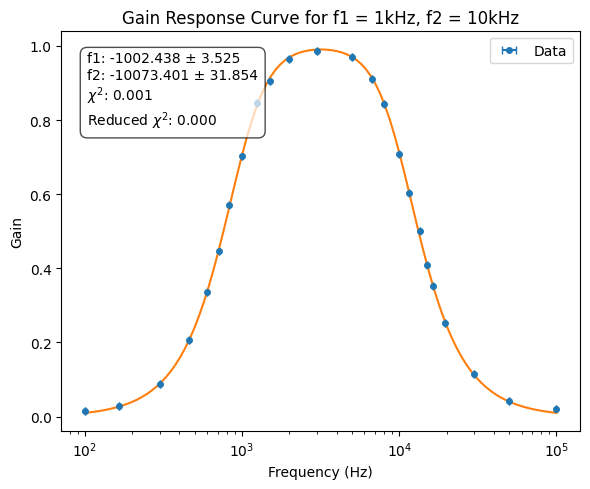

In [5]:
curve_1_output, curve_1_plot_data = butterworth_fit(df_1_10)
plot_gain_response_curve(curve_1_plot_data[0], curve_1_plot_data[1], \
                         curve_1_plot_data[2], fit_results = curve_1_output);

Text(0.5, 1.0, "'Gain Response Curve for f1 = 3kHz, f2 = 100kHz")

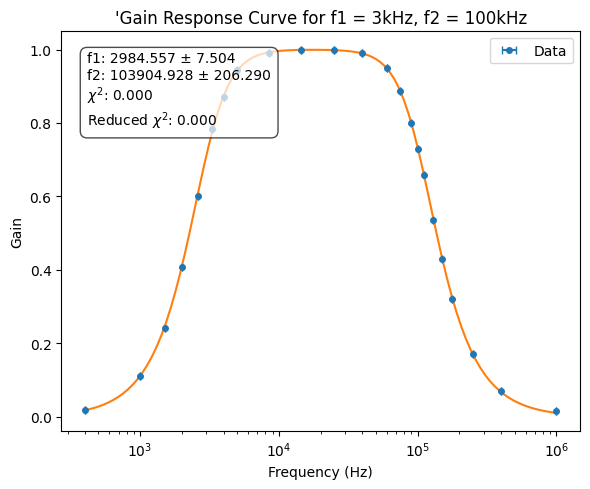

In [6]:
col_names_replace(df_3_100)
curve_2_output, curve_2_plot_data = butterworth_fit(df_3_100)
fig = plot_gain_response_curve(curve_2_plot_data[0], curve_2_plot_data[1], curve_2_plot_data[2], fit_results = curve_2_output, savefig="Images/gain_response_curve_example")
fig.axes[0].set_title("'Gain Response Curve for f1 = 3kHz, f2 = 100kHz") # TODO: Add functionality to change name of plot (either in fcn or afterwards)

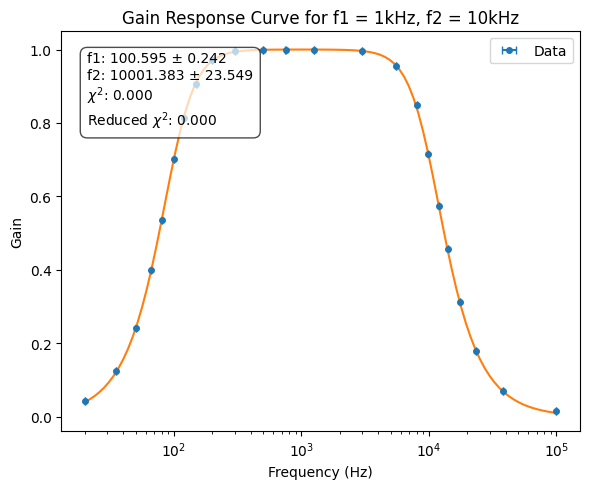

In [7]:
col_names_replace(df_100_10)
curve_3_output, curve_3_plot_data = butterworth_fit(df_100_10)
plot_gain_response_curve(curve_3_plot_data[0], curve_3_plot_data[1], curve_3_plot_data[2], fit_results = curve_3_output);

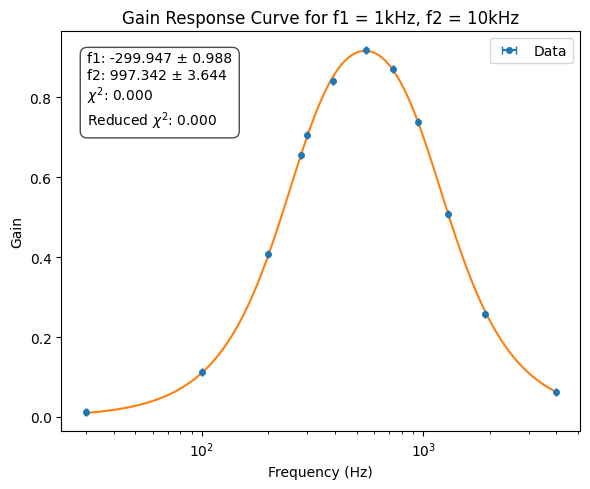

In [8]:
col_names_replace(df_300_1)
curve_4_output, curve_4_plot_data = butterworth_fit(df_300_1)
plot_gain_response_curve(curve_4_plot_data[0], curve_4_plot_data[1], curve_4_plot_data[2], fit_results = curve_4_output);

In [9]:
# For errors, thickness of trace and how well the function generator can hold its produced waveform for y errors
# Function generator errors for x error
# Datasheet https://res.cloudinary.com/iwh/image/upload/q_auto,g_center/assets/1/26/Documents/Protek/protekb8040fd_datasheet.pdf